In [7]:
import pandas as pd
import pandas as pd

# Load the Ford Car Dataset
df = pd.read_csv('./ford_car_dataset - ford_car_dataset.csv')

print('Dataset loaded successfully.')

Dataset loaded successfully.


In [11]:
# Display the first 10 rows
print("\nFirst 10 rows of the dataset:")
display(df.head(10))


First 10 rows of the dataset:


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0


In [ ]:
# Check the shape (number of rows and columns)
print("\nShape of the dataset (rows, columns):")
print(df.shape)

# Check data types of all columns
print("\nData types of all columns:")
display(df.info())


Shape of the dataset (rows, columns):
(17966, 9)

Data types of all columns:
<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.5 MB


None

In [10]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [12]:
print(df.isnull().value_counts())

model  year   price  transmission  mileage  fuelType  tax    mpg    engineSize
False  False  False  False         False    False     False  False  False         17966
Name: count, dtype: int64


In [13]:
print("duplicate values",df.duplicated().sum())

#remove duplicate value
df = df.drop_duplicates()
print("shape after removing duplicates value",df.shape)

duplicate values 154
shape after removing duplicates value (17812, 9)


<function matplotlib.pyplot.show(close=None, block=None)>

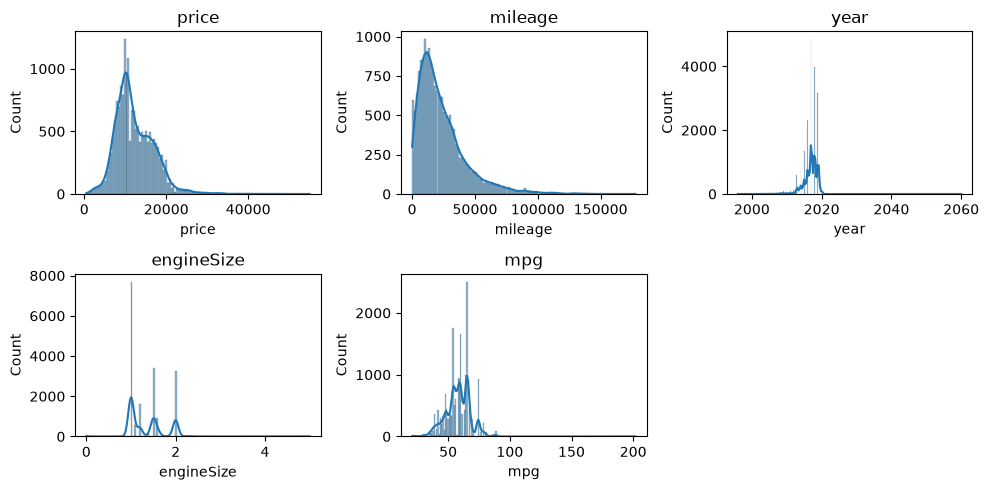

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = ("price","mileage","year","engineSize","mpg")
plt.figure(figsize=(10, 5))
for i, col in enumerate(num_cols):
    plt.subplot(2,3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show

C:\Users\good day\AppData\Local\Temp\ipykernel_10984\3377266292.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


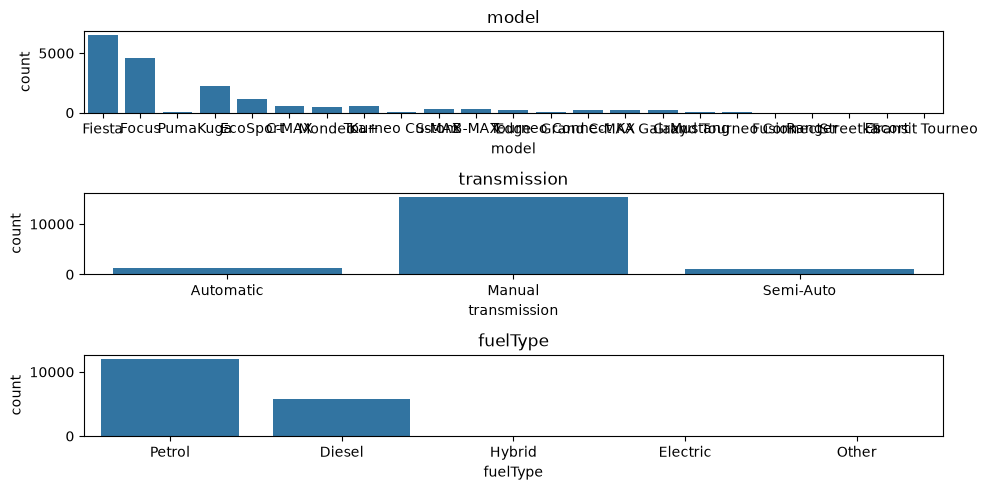

In [18]:
cat_cols = df.select_dtypes(include=['object']).columns
plt.figure(figsize=(10 ,5))
for i, col in enumerate(cat_cols):
    plt.subplot(len(cat_cols) ,1,i+1)
    sns.countplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

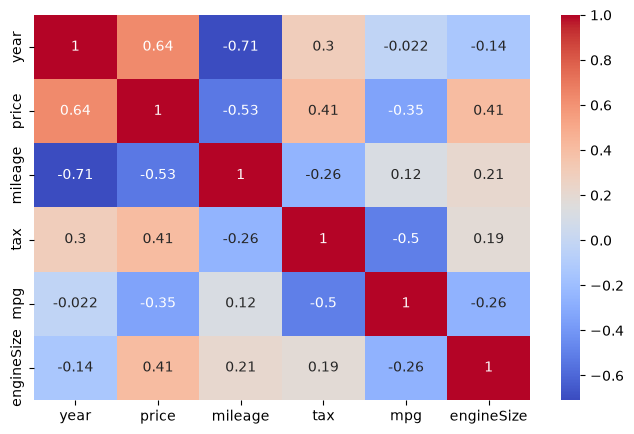

In [20]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only = True),
        annot=True, cmap='coolwarm')
plt.show()

In [21]:
target ="price"

x = df.drop("price", axis=1)

y = df["price"]

# independent features(x)
print("independent features")
print(x.columns)

# dependent features(y)
print("\ndependent features")
print(target)
print("shap of x" , x.shape)
print("shap of y" , y.shape)

independent features
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

dependent features
price
shap of x (17812, 8)
shap of y (17812,)


In [25]:
print("Before Encoding")
print(df[["fuelType","transmission"]].head())

encoded_df = pd.get_dummies(df, drop_first=True)
encoded_df = encoded_df.astype(int)
print("\nAfter Encoding")
print(encoded_df.head())
print("New Shape:", encoded_df.shape)

Before Encoding
  fuelType transmission
0   Petrol    Automatic
1   Petrol       Manual
2   Petrol       Manual
3   Petrol       Manual
4   Petrol    Automatic

After Encoding
   year  price  mileage  tax  mpg  engineSize  model_C-MAX  model_EcoSport  \
0  2017  12000    15944  150   57           1            0               0   
1  2018  14000     9083  150   57           1            0               0   
2  2017  13000    12456  150   57           1            0               0   
3  2019  17500    10460  145   40           1            0               0   
4  2019  16500     1482  145   48           1            0               0   

   model_Edge  model_Escort  ...  model_Streetka  model_Tourneo Connect  \
0           0             0  ...               0                      0   
1           0             0  ...               0                      0   
2           0             0  ...               0                      0   
3           0             0  ...               0       

In [26]:
from sklearn.preprocessing import StandardScaler

x = encoded_df.drop('price', axis=1)

scaler = StandardScaler()

scaler_data = scaler.fit_transform(x)

scaler_df = pd.DataFrame(scaler_data, columns=x.columns)

print(scaler_df.head())

       year   mileage       tax       mpg  engineSize  model_C-MAX  \
0  0.067059 -0.382994  0.591380 -0.042291   -0.446958    -0.177155   
1  0.554393 -0.736317  0.591380 -0.042291   -0.446958    -0.177155   
2  0.067059 -0.562616  0.591380 -0.042291   -0.446958    -0.177155   
3  1.041726 -0.665405  0.510777 -1.720193   -0.446958    -0.177155   
4  1.041726 -1.127749  0.510777 -0.930592   -0.446958    -0.177155   

   model_EcoSport  model_Edge  model_Escort  model_Fiesta  ...  \
0       -0.259896   -0.107903     -0.007493      1.317770  ...   
1       -0.259896   -0.107903     -0.007493     -0.758858  ...   
2       -0.259896   -0.107903     -0.007493     -0.758858  ...   
3       -0.259896   -0.107903     -0.007493      1.317770  ...   
4       -0.259896   -0.107903     -0.007493      1.317770  ...   

   model_Streetka  model_Tourneo Connect  model_Tourneo Custom  \
0       -0.010597              -0.042424             -0.062361   
1       -0.010597              -0.042424          

In [27]:
# show first 5 rows
scaler_df.head()

,year,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Escort,model_Fiesta,...,model_Streetka,model_Tourneo Connect,model_Tourneo Custom,model_Transit Tourneo,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.042291,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,1.317770,...,-0.010597,-0.042424,-0.062361,-0.007493,-2.516557,-0.253434,-0.010597,-0.035166,-0.007493,0.688753
1,0.554393,-0.736317,0.591380,-0.042291,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,-0.758858,...,-0.010597,-0.042424,-0.062361,-0.007493,0.397368,-0.253434,-0.010597,-0.035166,-0.007493,0.688753
2,0.067059,-0.562616,0.591380,-0.042291,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,-0.758858,...,-0.010597,-0.042424,-0.062361,-0.007493,0.397368,-0.253434,-0.010597,-0.035166,-0.007493,0.688753
3,1.041726,-0.665405,0.510777,-1.720193,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,1.317770,...,-0.010597,-0.042424,-0.062361,-0.007493,0.397368,-0.253434,-0.010597,-0.035166,-0.007493,0.688753
4,1.041726,-1.127749,0.510777,-0.930592,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,1.317770,...,-0.010597,-0.042424,-0.062361,-0.007493,-2.516557,-0.253434,-0.010597,-0.035166,-0.007493,0.688753


In [28]:
from sklearn.model_selection import train_test_split

# Redefine y_target using the encoded_df for consistency
y_target = encoded_df["price"]

x_train, x_test, y_train, y_test = train_test_split(scaler_df, y_target, test_size=0.33, random_state=42)

print("shape of x_train", x_train.shape)
print("shape of x_test", x_test.shape)
print("shape of y_train", y_train.shape)
print("shape of y_test", y_test.shape)

shape of x_train (11934, 33)
shape of x_test (5878, 33)
shape of y_train (11934,)
shape of y_test (5878,)


In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

print("intercept")
print(model.intercept_)
print("coefficient")
print(model.coef_)

intercept
12286.453016871372
coefficient
[ 2.15511130e+03 -1.19266245e+03  1.20192189e+00 -9.60282307e+02
  8.71188524e+02  1.66092442e+02  2.89191914e+02  8.47657943e+02
  1.10864340e+02  3.99872893e+02  1.27500953e+03  1.01365942e+02
  6.60379642e+02  1.37056719e+02  2.35904109e+02 -7.35478211e+01
 -5.14061669e+02  1.07362624e+03  3.66508531e+02  7.55260820e+02
  4.94017751e+02  3.80251367e+01  6.83534960e+02  5.27249995e+01
  1.44793417e+02  3.79432772e+02  8.05706638e+00 -1.92929960e+02
 -5.46547038e+01  1.82792844e+01  2.74443908e+02  7.43149745e+00
 -5.49301813e+02]


In [41]:
y_pred = model.predict(x_test)
results = pd.DataFrame({'Actual': y_test[:10].values, 'Predicted': y_pred[:10]})
display(results.head(10))

,Actual,Predicted
0,22975,22212.022438
1,18000,15038.347241
2,18500,16540.917704
3,9985,11703.292708
4,7998,10969.421865
5,13990,13171.356205
6,5000,5772.415842
7,15450,15120.944890
8,6160,6448.433255
9,12495,12474.440979


In [35]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, model.predict(x_test))
print("R-squared:", r2)

R-squared: 0.8310456871453885


In [ ]:
import joblib
 # save model
joblib.dump(model, 'model.pkl')

#save sclar
joblib.dump(scaler, 'scaler.pkl')

#save column name
joblib.dump(x.columns.tolist(), 'columns.pkl')
print("model, scaler and columns saved successfully.")

model, scaler and columns saved successfully.
